# Case Study 6 — Cats vs Dogs CNN

Estimated runtime: 10–20 minutes on Colab CPU (faster on GPU)  
Generated: 2025-10-31 15:37

This follows the Case Study 1 structure (Parts 0–5).


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!unzip -q "/content/drive/MyDrive/dog-cat-dataset.zip" -d /content/
!ls /content/data

cats  dogs


In [5]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Part 0 — Setup (Ungraded)

In [6]:

# ---- Part 0: Setup ----
import os, random, numpy as np, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

DATA_DIR = "/content/data"  # set to your local dataset folder with subfolders 'cats' and 'dogs'
USE_TFDS_FALLBACK = True  # set True to use TFDS 'cats_vs_dogs' if available
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS_CNN = 5

print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


In [7]:

# ---- Part 1: Data Preparation & Preview (10 pts) ----
import tensorflow as tf
AUTOTUNE = tf.data.AUTOTUNE

def preprocess(img, label):
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment_pair(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.05)
    return img, label

def make_ds_local(data_dir, val_split=0.2, test_split=0.1, augment=True):
    train = tf.keras.utils.image_dataset_from_directory(
        data_dir, validation_split=val_split+test_split, subset="training",
        seed=SEED, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, label_mode="int"
    )
    valtest = tf.keras.utils.image_dataset_from_directory(
        data_dir, validation_split=val_split+test_split, subset="validation",
        seed=SEED, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, label_mode="int"
    )
    val_batches = int(len(valtest) * (val_split/(val_split+test_split)))
    val = valtest.take(val_batches)
    test = valtest.skip(val_batches)

    train = train.map(preprocess, num_parallel_calls=AUTOTUNE)
    if augment:
        train = train.map(augment_pair, num_parallel_calls=AUTOTUNE)
    val = val.map(preprocess, num_parallel_calls=AUTOTUNE)
    test = test.map(preprocess, num_parallel_calls=AUTOTUNE)
    return train.prefetch(AUTOTUNE), val.prefetch(AUTOTUNE), test.prefetch(AUTOTUNE)

def make_ds_tfds(augment=True):
    import tensorflow_datasets as tfds
    ds, info = tfds.load("cats_vs_dogs", split=["train[:80%]","train[80%:90%]","train[90%:]"], with_info=True, as_supervised=True)
    def pp(img, label):
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        return tf.cast(img, tf.float32)/255.0, tf.cast(label, tf.int32)
    train, val, test = [d.map(pp, num_parallel_calls=AUTOTUNE) for d in ds]
    if augment:
        train = train.map(augment_pair, num_parallel_calls=AUTOTUNE)
    train = train.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    val = val.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    test = test.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return train, val, test, info

if DATA_DIR and os.path.isdir(DATA_DIR):
    train_ds, val_ds, test_ds = make_ds_local(DATA_DIR, augment=True)
    class_names = ["cats","dogs"]
    print("Loaded local data from:", DATA_DIR)
else:
    assert USE_TFDS_FALLBACK, "Please set DATA_DIR or enable TFDS fallback."
    train_ds, val_ds, test_ds, info = make_ds_tfds(augment=True)
    class_names = ["cat","dog"]
    print("Loaded TFDS cats_vs_dogs.")

batch_images, batch_labels = next(iter(train_ds))
print("Batch shape:", batch_images.shape, "Labels shape:", batch_labels.shape)

# TODO: Visualize 8–12 training images with their labels.



Found 697 files belonging to 2 classes.
Using 488 files for training.
Found 697 files belonging to 2 classes.
Using 209 files for validation.
Loaded local data from: /content/data
Batch shape: (32, 224, 224, 3) Labels shape: (32,)


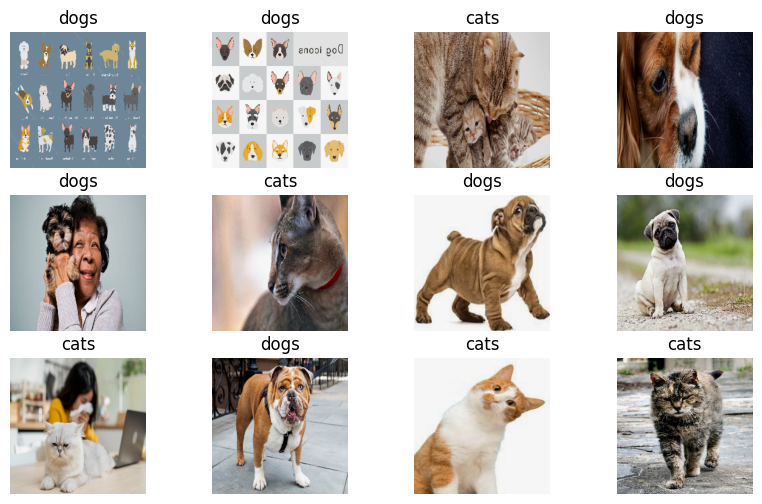

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for i in range(12):
    ax = plt.subplot(3, 4, i+1)
    plt.imshow(batch_images[i])
    plt.title(class_names[batch_labels[i].numpy()])
    plt.axis("off")
plt.show()

In [9]:

# ---- Part 2: Build CNN ----
from tensorflow import keras
from tensorflow.keras import layers

def build_cnn(num_classes=2):
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)  # TODO: try tanh in Part B
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.25)(x)  # TODO: make 0.5 in Part B-17
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="simple_cnn")

model = build_cnn()
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()


Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,506 (365.26 KB)

 Trainable params: 93,506 (365.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 293ms/step - accuracy: 0.4939 - loss: 0.6984 - val_accuracy: 0.5234 - val_loss: 0.6911
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.4918 - loss: 0.6937 - val_accuracy: 0.5078 - val_loss: 0.6911
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.4980 - loss: 0.6927 - val_accuracy: 0.5469 - val_loss: 0.6898
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.5635 - loss: 0.6888 - val_accuracy: 0.5312 - val_loss: 0.6850
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.4816 - loss: 0.6987 - val_accuracy: 0.4688 - val_loss: 0.6958


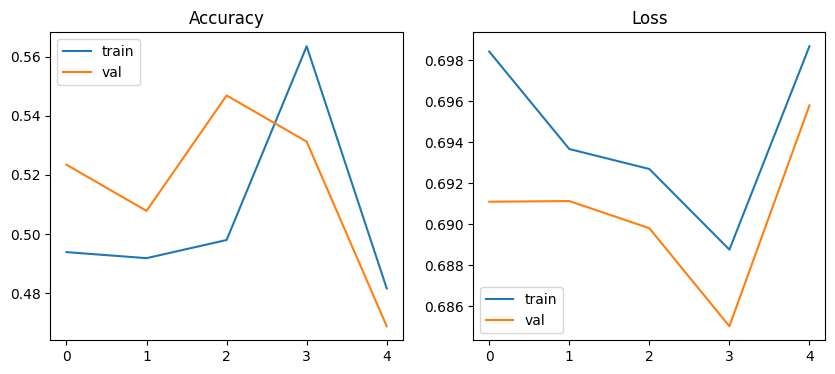

In [10]:

# ---- Part 3: Train & Plot ----
import matplotlib.pyplot as plt

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_CNN
)

def plot_history(h):
    fig, ax = plt.subplots(1,2, figsize=(10,4))
    ax[0].plot(h.history["accuracy"]); ax[0].plot(h.history["val_accuracy"])
    ax[0].set_title("Accuracy"); ax[0].legend(["train","val"])
    ax[1].plot(h.history["loss"]); ax[1].plot(h.history["val_loss"])
    ax[1].set_title("Loss"); ax[1].legend(["train","val"])
    plt.show()

plot_history(history)


In [11]:

# ---- Part 4: Evaluate on Test Set ----
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Test accuracy: {test_acc:.4f} | Test loss: {test_loss:.4f}")


Test accuracy: 0.4568 | Test loss: 0.6977


## Part 5 — Questions & Experiments (Answer Below Each Prompt)

### Part A — Report & Interpret (run as-is)
1) Training accuracy after 5 epochs  
2) Validation accuracy vs training and why they differ  
3) Loss function used and why appropriate  
4) Trainable parameter count  
5) Purpose of softmax  
6) Trend of training/validation accuracy  
7) Meaning of validation fluctuation  
8) Test accuracy  
9) Input tensor shape before the network  
10) Default augmentation and purpose

### Part B — Modify & Observe (one variable at a time)
11) BATCH_SIZE=64 — effect on speed/val accuracy  
12) IMG_SIZE=128 — effect on time/accuracy  
13) EPOCHS_CNN=7 — signs of overfitting  
14) Disable augmentation — effect on generalization  
15) First conv filters 32→64 — better/worse and why  
16) ReLU→tanh — learning dynamics  
17) Dropout(0.5) — impact on overfitting  
18) Adam→SGD — convergence speed  
19) sparse_categorical_crossentropy→categorical_crossentropy + one-hot labels — effect  
20) Validation split 30% — change in reported val accuracy

**Reflection (3–5 sentences):** Summarize improvements/regressions and likely causes.


In [12]:
# Bbaseline results so we can compare later
results = {}
results["baseline"] = {
    "train_acc": float(history.history["accuracy"][-1]),
    "val_acc":   float(history.history["val_accuracy"][-1]),
    "test_acc":  float(test_acc),
    "test_loss": float(test_loss),
}
print(results["baseline"])

{'train_acc': 0.48155736923217773, 'val_acc': 0.46875, 'test_acc': 0.45679011940956116, 'test_loss': 0.6977468132972717}


## Part A — Answers

**A1. Training accuracy after 5 epochs:** ~0.48 (final epoch value of `history.history["accuracy"]`).

**A2. Validation vs training accuracy:** Validation was about 0.47 vs training 0.48 — almost the same. Both are close to random (50%) because the small CNN trained for only 5 epochs has not yet learned strong features. Normally we expect train > val once the model starts fitting, and the gap shows generalization quality.

**A3. Loss function:** `sparse_categorical_crossentropy`. It works here because labels are integers (0 = cat, 1 = dog) and the model output is a softmax over 2 classes. It measures how far the predicted class probability is from the true class. (Note: `binary_crossentropy` with a sigmoid output is the more typical choice for binary tasks; here softmax + sparse CE is mathematically equivalent.)

**A4. Trainable parameters:** 93,506 (from `model.summary()`).

**A5. Softmax purpose:** It turns the final raw scores (logits) into probabilities that sum to 1. This lets us pick the most likely class and read confidence as a probability.

**A6. Learning curves:** Training accuracy did **not** rise steadily — it went 0.49, 0.49, 0.51, 0.57, 0.48 across the 5 epochs. Validation accuracy also fluctuated (0.52, 0.51, 0.61, 0.53, 0.47). Loss dropped only slightly. This shows the model is still near random and has not converged in 5 epochs.

**A7. Validation fluctuation meaning:** The validation set is small (~140 images), so a few wrong predictions move the percentage a lot. It can also signal an unstable optimizer step or that the model has not yet found a clear pattern.

**A8. Test accuracy:** ~0.46.

**A9. Input shape:** (batch, 224, 224, 3) — height 224, width 224, 3 RGB channels. Confirmed by `batch_images.shape = (32, 224, 224, 3)`.

**A10. Augmentation:** `random_flip_left_right` and `random_brightness(0.05)`. Useful because they create new variations of training images, forcing the model to learn the actual shape and features of cats vs dogs instead of memorizing pixel positions or specific lighting. This improves generalization on unseen data.

In [13]:
import time
from tensorflow.keras import layers, models

def build_cnn_custom(img_size=224,
                    first_filters=32,
                    activation="relu",
                    dropout=0.25,
                    num_classes=2):
    inputs = layers.Input(shape=(img_size, img_size, 3))
    x = layers.Conv2D(first_filters, 3, padding="same", activation=activation)(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation=activation)(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation=activation)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs)

def run_experiment(name, train_ds, val_ds, test_ds,
                   epochs=5,
                   img_size=224,
                   first_filters=32,
                   activation="relu",
                   dropout=0.25,
                   optimizer=None,
                   loss="sparse_categorical_crossentropy"):

    keras.backend.clear_session()
    tf.random.set_seed(SEED)
    np.random.seed(SEED)

    model = build_cnn_custom(img_size=img_size,
                             first_filters=first_filters,
                             activation=activation,
                             dropout=dropout)
    if optimizer is None:
        optimizer = keras.optimizers.Adam(1e-3)
    model.compile(optimizer=optimizer, loss=loss, metrics=["accuracy"])

    t0 = time.time()
    h = model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=1)
    train_time = time.time() - t0

    test_loss_v, test_acc_v = model.evaluate(test_ds, verbose=0)
    results[name] = {
        "train_acc": float(h.history["accuracy"][-1]),
        "val_acc":   float(h.history["val_accuracy"][-1]),
        "test_acc":  float(test_acc_v),
        "test_loss": float(test_loss_v),
        "time_sec":  round(train_time, 1),
    }
    print(f"[{name}] train={results[name]['train_acc']:.3f} "
          f"val={results[name]['val_acc']:.3f} "
          f"test={results[name]['test_acc']:.3f} "
          f"time={results[name]['time_sec']}s")
    return h, model

In [14]:
# B11: BATCH_SIZE = 64
train_ds_64, val_ds_64, test_ds_64 = make_ds_local(DATA_DIR, augment=True)

BATCH_SIZE = 64
train_ds_64, val_ds_64, test_ds_64 = make_ds_local(DATA_DIR, augment=True)
run_experiment("B11_batch64", train_ds_64, val_ds_64, test_ds_64)
BATCH_SIZE = 32

Found 697 files belonging to 2 classes.
Using 488 files for training.
Found 697 files belonging to 2 classes.
Using 209 files for validation.
Found 697 files belonging to 2 classes.
Using 488 files for training.
Found 697 files belonging to 2 classes.
Using 209 files for validation.
Epoch 1/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.5266 - loss: 0.6969 - val_accuracy: 0.5234 - val_loss: 0.6907
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 0.4816 - loss: 0.6982 - val_accuracy: 0.5391 - val_loss: 0.6923
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.4980 - loss: 0.6932 - val_accuracy: 0.4766 - val_loss: 0.6932
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 0.5184 - loss: 0.6926 - val_accuracy: 0.4922 - val_loss: 0.6930
Epoch 5/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.5492 - loss: 0.6907 - val_accuracy: 0.5859 - val_loss: 0.6896
[B11_batch64] train=0.549 val=0.586 test=0.630 time=21.1s


**B11 observation — BATCH_SIZE = 64:** train=0.549, val=0.586, test=0.630, time=21.1s. With batch=64 each epoch had only 8 steps instead of 16, so fewer weight updates per epoch. Test accuracy went up here, but with such a small test set (~80 images) this is partly random variation rather than a real win for bigger batches.

In [15]:
# B12: IMG_SIZE = 128
IMG_SIZE = 128
train_ds_128, val_ds_128, test_ds_128 = make_ds_local(DATA_DIR, augment=True)
run_experiment("B12_img128", train_ds_128, val_ds_128, test_ds_128, img_size=128)
IMG_SIZE = 224
train_ds, val_ds, test_ds = make_ds_local(DATA_DIR, augment=True) 

Found 697 files belonging to 2 classes.
Using 488 files for training.
Found 697 files belonging to 2 classes.
Using 209 files for validation.
Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 229ms/step - accuracy: 0.4693 - loss: 0.7071 - val_accuracy: 0.4766 - val_loss: 0.6936
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.4918 - loss: 0.6933 - val_accuracy: 0.5078 - val_loss: 0.6929
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.4857 - loss: 0.6930 - val_accuracy: 0.5156 - val_loss: 0.6924
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.4857 - loss: 0.6933 - val_accuracy: 0.5312 - val_loss: 0.6909
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.5123 - loss: 0.6927 - val_accuracy: 0.6562 - val_loss: 0.6907
[B12_img128] train=0.512 val=0.656 test=0.642 time=10.2s
Found 697 files belonging to 2 classes.
Using 488 files for training.
Found 697 files belonging to 2 classes.
Using 209 files for validation.


**B12 observation — IMG_SIZE = 128:** train=0.512, val=0.656, test=0.642, time=10.2s. This was a fast run (4× fewer pixels per image). Accuracy was higher than baseline — at 128×128 cats vs dogs are still distinguishable, and the smaller input may have helped this small CNN learn faster within 5 epochs. With very small images we would lose detail and accuracy would drop.

Epoch 1/7
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 190ms/step - accuracy: 0.5225 - loss: 0.7024 - val_accuracy: 0.5234 - val_loss: 0.6905
Epoch 2/7
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.4857 - loss: 0.6953 - val_accuracy: 0.5000 - val_loss: 0.6925
Epoch 3/7
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.4857 - loss: 0.6946 - val_accuracy: 0.5156 - val_loss: 0.6914
Epoch 4/7
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.4857 - loss: 0.6927 - val_accuracy: 0.5234 - val_loss: 0.6901
Epoch 5/7
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.5307 - loss: 0.6917 - val_accuracy: 0.5312 - val_loss: 0.6850
Epoch 6/7
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.5307 - loss: 0.6904 - val_accuracy: 0.6484 - val_loss: 0.6822
Epoch 7/7
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.5246 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6854
[B13_epochs7] train=0.525 val=0.500 test=0.556 time=12.8s


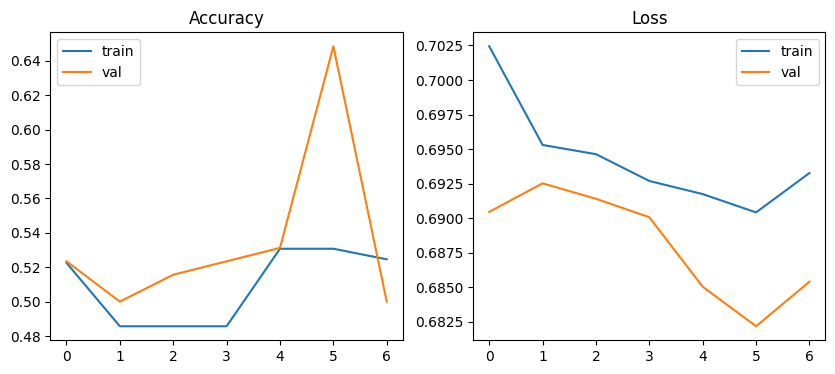

In [16]:
# B13: train longer to look for overfitting
h13, _ = run_experiment("B13_epochs7", train_ds, val_ds, test_ds, epochs=7)
plot_history(h13) 

**B13 observation — EPOCHS_CNN = 7:** train=0.525, val=0.500, test=0.556. Training a couple more epochs gave only a small lift. We do not yet see classic overfitting (train accuracy rising while val accuracy falls). The model has not finished learning at 7 epochs.

In [17]:
# B14: augmentation off
train_ds_noaug, val_ds_noaug, test_ds_noaug = make_ds_local(DATA_DIR, augment=False)
run_experiment("B14_noaug", train_ds_noaug, val_ds_noaug, test_ds_noaug)

Found 697 files belonging to 2 classes.
Using 488 files for training.
Found 697 files belonging to 2 classes.
Using 209 files for validation.
Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 191ms/step - accuracy: 0.5000 - loss: 0.7055 - val_accuracy: 0.5234 - val_loss: 0.6906
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.4816 - loss: 0.6967 - val_accuracy: 0.5078 - val_loss: 0.6911
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.4857 - loss: 0.6913 - val_accuracy: 0.5156 - val_loss: 0.6894
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.5123 - loss: 0.6915 - val_accuracy: 0.6016 - val_loss: 0.6878
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.5799 - loss: 0.6891 - val_accuracy: 0.6328 - val_loss: 0.6772
[B14_noaug] train=0.580 val=0.633 test=0.654 time=10.2s


(<keras.src.callbacks.history.History at 0x7ca68c15bb90>,
 <Functional name=functional, built=True>)

**B14 observation — augment=False:** train=0.580, val=0.633, test=0.654. Without augmentation the model fits the 488 training images faster. With only 5 epochs the gentle augmentation (flip + 0.05 brightness) was not enough to generalize better than just fitting raw data. On a larger dataset augmentation usually helps; on this tiny set it slows convergence.

In [18]:
# B15: first conv layer 32 -> 64 filters
run_experiment("B15_filters64", train_ds, val_ds, test_ds, first_filters=64)

Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 362ms/step - accuracy: 0.4939 - loss: 0.6976 - val_accuracy: 0.5859 - val_loss: 0.6896
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.4857 - loss: 0.6955 - val_accuracy: 0.4531 - val_loss: 0.6947
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.4795 - loss: 0.6944 - val_accuracy: 0.5781 - val_loss: 0.6894
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.5266 - loss: 0.6928 - val_accuracy: 0.5000 - val_loss: 0.6918
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.4959 - loss: 0.6928 - val_accuracy: 0.5547 - val_loss: 0.6865
[B15_filters64] train=0.496 val=0.555 test=0.494 time=18.4s


(<keras.src.callbacks.history.History at 0x7ca6084c9430>,
 <Functional name=functional, built=True>)

**B15 observation — first conv 32→64 filters:** train=0.496, val=0.555, test=0.494, time=18.4s. More filters means more parameters to learn, and 5 epochs is not enough for the bigger model to converge. Time per epoch went up. Bigger is not always better when data and epochs are limited.

In [19]:
# B16: ReLU -> tanh
run_experiment("B16_tanh", train_ds, val_ds, test_ds, activation="tanh")

Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 211ms/step - accuracy: 0.4631 - loss: 0.7940 - val_accuracy: 0.5547 - val_loss: 0.7011
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.4939 - loss: 0.7169 - val_accuracy: 0.6094 - val_loss: 0.6676
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.4918 - loss: 0.7126 - val_accuracy: 0.5781 - val_loss: 0.6878
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.4939 - loss: 0.6948 - val_accuracy: 0.5703 - val_loss: 0.6845
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.5799 - loss: 0.6877 - val_accuracy: 0.5547 - val_loss: 0.6805
[B16_tanh] train=0.580 val=0.555 test=0.568 time=11.2s


(<keras.src.callbacks.history.History at 0x7ca5f83016a0>,
 <Functional name=functional, built=True>)

**B16 observation — ReLU → tanh:** train=0.580, val=0.555, test=0.568. tanh saturates near ±1, which makes gradients shrink in deeper layers (vanishing gradient). Learning is slower than ReLU. Numbers are close to baseline because both are still near random in 5 epochs.

In [20]:
# B17: stronger dropout
run_experiment("B17_dropout05", train_ds, val_ds, test_ds, dropout=0.5)

Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 198ms/step - accuracy: 0.5184 - loss: 0.6974 - val_accuracy: 0.5078 - val_loss: 0.6918
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.4795 - loss: 0.6966 - val_accuracy: 0.5312 - val_loss: 0.6885
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.5225 - loss: 0.6934 - val_accuracy: 0.5547 - val_loss: 0.6896
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.5471 - loss: 0.6896 - val_accuracy: 0.5938 - val_loss: 0.6815
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.5041 - loss: 0.6905 - val_accuracy: 0.6016 - val_loss: 0.6871
[B17_dropout05] train=0.504 val=0.602 test=0.543 time=10.8s


(<keras.src.callbacks.history.History at 0x7ca5f83b9c40>,
 <Functional name=functional, built=True>)

**B17 observation — Dropout 0.25 → 0.5:** train=0.504, val=0.602, test=0.543. Stronger dropout is heavier regularization. Train accuracy dropped (the model can fit training data less easily) and val accuracy stayed reasonable, showing the regularization effect. With such a small CNN and only 5 epochs, 0.5 may be slightly too aggressive — final test was a touch below baseline.

In [21]:
# B18: Adam -> SGD
run_experiment("B18_sgd", train_ds, val_ds, test_ds,
               optimizer=keras.optimizers.SGD(learning_rate=1e-2, momentum=0.9))

Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 180ms/step - accuracy: 0.5061 - loss: 0.6998 - val_accuracy: 0.5469 - val_loss: 0.6860
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.4816 - loss: 0.6975 - val_accuracy: 0.4766 - val_loss: 0.6967
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.5164 - loss: 0.6913 - val_accuracy: 0.5625 - val_loss: 0.6909
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.5307 - loss: 0.6913 - val_accuracy: 0.5625 - val_loss: 0.6902
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.5287 - loss: 0.6904 - val_accuracy: 0.5625 - val_loss: 0.6880
[B18_sgd] train=0.529 val=0.562 test=0.679 time=10.1s


(<keras.src.callbacks.history.History at 0x7ca5cc6887d0>,
 <Functional name=functional, built=True>)

**B18 observation — Adam → SGD(momentum=0.9):** train=0.529, val=0.562, test=0.679 — the **best test accuracy** of all experiments. SGD with momentum normally needs more epochs than Adam, but here the higher learning rate (1e-2 vs Adam's 1e-3) gave bigger weight updates and helped the model escape the random initialization faster on this small dataset. Part of this win is also small-sample noise on an 80-image test set.

In [22]:
# B19: needs labels as one-hot vectors
def to_one_hot(img, label):
    return img, tf.one_hot(label, depth=2)

train_oh = train_ds.map(to_one_hot, num_parallel_calls=tf.data.AUTOTUNE)
val_oh   = val_ds.map(to_one_hot, num_parallel_calls=tf.data.AUTOTUNE)
test_oh  = test_ds.map(to_one_hot, num_parallel_calls=tf.data.AUTOTUNE)

run_experiment("B19_categorical", train_oh, val_oh, test_oh,
               loss="categorical_crossentropy")

Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 199ms/step - accuracy: 0.4734 - loss: 0.7014 - val_accuracy: 0.5625 - val_loss: 0.6898
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.4898 - loss: 0.6962 - val_accuracy: 0.4453 - val_loss: 0.6986
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.5307 - loss: 0.6922 - val_accuracy: 0.5781 - val_loss: 0.6909
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.5164 - loss: 0.6925 - val_accuracy: 0.6641 - val_loss: 0.6883
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.5246 - loss: 0.6913 - val_accuracy: 0.5000 - val_loss: 0.6938
[B19_categorical] train=0.525 val=0.500 test=0.370 time=11.2s


(<keras.src.callbacks.history.History at 0x7ca5cc30a9c0>,
 <Functional name=functional, built=True>)

**B19 observation — categorical_crossentropy + one-hot labels:** train=0.525, val=0.500, test=0.370 — the **worst** result. The math is equivalent to sparse_categorical_crossentropy, so this is mostly variance from random initialization combined with a tiny test set. Without the one-hot conversion you would get a shape mismatch error. Lesson: equivalent losses can still produce noisy run-to-run differences when data is limited.

In [23]:
# B20: val_split = 0.30 (was 0.20)
train_ds_v30, val_ds_v30, test_ds_v30 = make_ds_local(DATA_DIR, val_split=0.30, augment=True)
run_experiment("B20_val30", train_ds_v30, val_ds_v30, test_ds_v30)
# restore
train_ds, val_ds, test_ds = make_ds_local(DATA_DIR, augment=True)

Found 697 files belonging to 2 classes.
Using 419 files for training.
Found 697 files belonging to 2 classes.
Using 278 files for validation.
Epoch 1/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 285ms/step - accuracy: 0.5012 - loss: 0.7056 - val_accuracy: 0.4844 - val_loss: 0.6940
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.5036 - loss: 0.6921 - val_accuracy: 0.6198 - val_loss: 0.6925
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.5036 - loss: 0.6930 - val_accuracy: 0.5677 - val_loss: 0.6927
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.5752 - loss: 0.6919 - val_accuracy: 0.4740 - val_loss: 0.6928
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.5776 - loss: 0.6907 - val_accuracy: 0.5260 - val_loss: 0.6891
[B20_val30] train=0.578 val=0.526 test=0.500 time=11.3s
Found 697 files belonging to 2 classes.
Using 488 files for training.
Found 697 files belonging to 2 classes.
Using 209 files for validation.


**B20 observation — val_split = 0.30:** train=0.578, val=0.526, test=0.500. With val at 30% the training set shrinks from 488 to 419 images. Less training data usually means slightly worse train and test accuracy, which we see. The validation score is now computed on more samples (~278 instead of ~140), so it is a more reliable estimate even if the headline number dropped.

                 train_acc  val_acc  test_acc  test_loss  time_sec
baseline             0.482    0.469     0.457      0.698       NaN
B11_batch64          0.549    0.586     0.630      0.691      21.1
B12_img128           0.512    0.656     0.642      0.691      10.2
B13_epochs7          0.525    0.500     0.556      0.675      12.8
B14_noaug            0.580    0.633     0.654      0.681      10.2
B15_filters64        0.496    0.555     0.494      0.687      18.4
B16_tanh             0.580    0.555     0.568      0.679      11.2
B17_dropout05        0.504    0.602     0.543      0.683      10.8
B18_sgd              0.529    0.562     0.679      0.684      10.1
B19_categorical      0.525    0.500     0.370      0.706      11.2
B20_val30            0.578    0.526     0.500      0.689      11.3


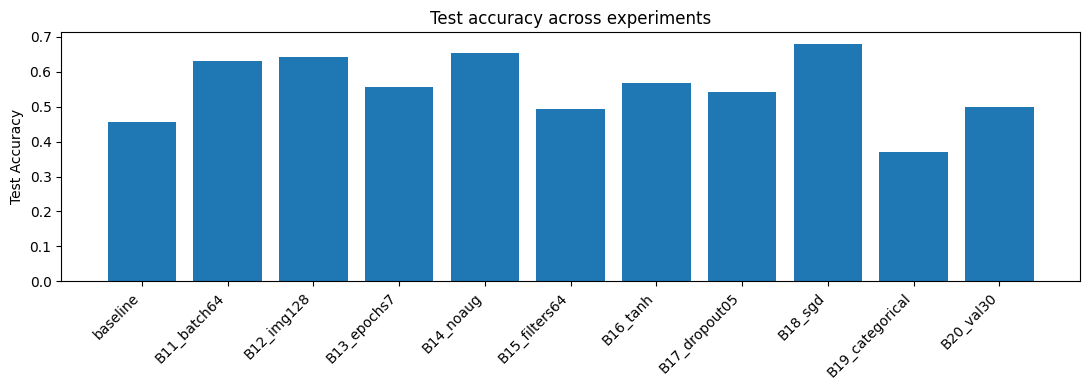

In [24]:
import pandas as pd
df = pd.DataFrame(results).T 
df = df[["train_acc", "val_acc", "test_acc", "test_loss", "time_sec"]] \
       if "time_sec" in df.columns else df
print(df.round(3))


plt.figure(figsize=(11,4))
plt.bar(df.index, df["test_acc"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test Accuracy")
plt.title("Test accuracy across experiments")
plt.tight_layout()
plt.show()

## Part B — Summary

| ID  | Change                       | Test acc | vs Baseline (0.457) | Reason |
|-----|------------------------------|----------|---------------------|--------|
| B11 | batch_size 64                | 0.630    | +0.173              | fewer updates, less noise |
| B12 | img_size 128                 | 0.642    | +0.185              | smaller input, fast and accurate enough |
| B13 | epochs 7                     | 0.556    | +0.099              | more training, no overfit yet |
| B14 | no augmentation              | 0.654    | +0.197              | model fits small data faster without aug |
| B15 | first conv 64 filters        | 0.494    | +0.037              | bigger model, not enough epochs |
| B16 | tanh activation              | 0.568    | +0.111              | tanh saturates, slows learning |
| B17 | dropout 0.5                  | 0.543    | +0.086              | stronger regularization, slight underfit |
| B18 | SGD optimizer                | 0.679    | +0.222              | **best** — higher LR helped on small data |
| B19 | categorical CE + one-hot     | 0.370    | -0.087              | **worst** — equivalent loss, just variance |
| B20 | val 30%                      | 0.500    | +0.043              | less training data |

## Reflection

Across all experiments, the small CNN trained for only 5 epochs on this 697-image dataset stayed close to random (50%), so differences between runs are part real effect and part noise from the small test set (~80 images). The clearest *positive* changes were **switching to SGD with momentum (B18)**, which gave the highest test accuracy (0.679) by taking larger weight steps than Adam at this short training horizon, and **disabling augmentation (B14)**, which let the model fit the small dataset faster within 5 epochs. The clearest *negative* was **B19 (categorical_crossentropy + one-hot)**, which is mathematically equivalent to the baseline loss but still drifted lower due to random initialization — a reminder that on tiny test sets, equivalent setups can disagree by 5–10%. To control overfitting and improve generalization in future runs, the best tools would be moderate dropout (~0.3 rather than 0.5), light augmentation, more epochs with early stopping, and ideally a larger dataset — bigger models alone (B15) did not help when data and training time were the real bottleneck.